In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [16]:
dfs_00 = pd.read_csv('../evaluation/bfs-vs-dfs-bfs-00.csv')
dfs_00.set_index('Unnamed: 0', inplace=True)
dfs_01 = pd.read_csv('../evaluation/bfs-vs-dfs-bfs-01.csv')
dfs_01.set_index('Unnamed: 0', inplace=True)
dfs_10 = pd.read_csv('../evaluation/bfs-vs-dfs-bfs-10.csv')
dfs_10.set_index('Unnamed: 0', inplace=True)
dfs_11 = pd.read_csv('../evaluation/bfs-vs-dfs-bfs-11.csv')
dfs_11.set_index('Unnamed: 0', inplace=True)
random_dfs = pd.read_csv('../evaluation/bfs-vs-dfs-bfs-random.csv')
random_dfs.set_index('Unnamed: 0', inplace=True)

Text(0.5, 0.97, 'First passage time ratio for different processing orders derived from Francescos ordering compared to random dfs tree order')

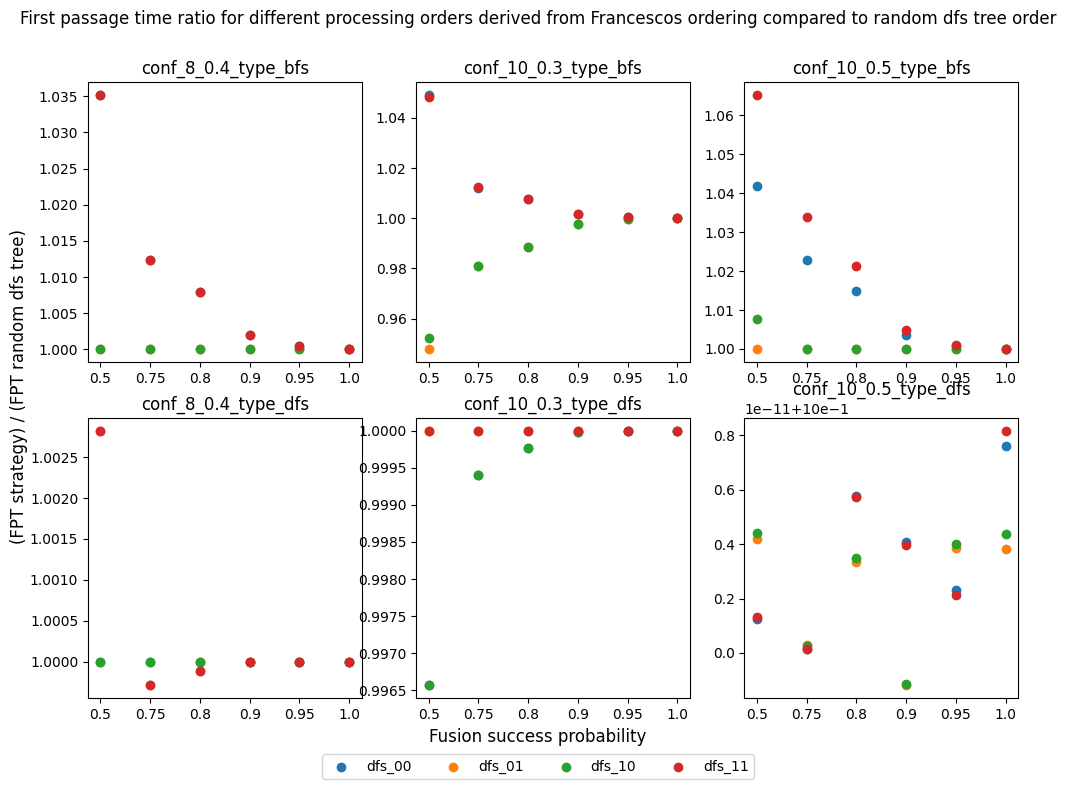

In [18]:
success_probabilities = ['0.5', '0.75', '0.8', '0.9','0.95','1.0'] #0.1 omitted
configurations = [['conf_8_0.4_type_bfs','conf_8_0.4_type_dfs'],['conf_10_0.3_type_bfs','conf_10_0.3_type_dfs'],['conf_10_0.5_type_bfs','conf_10_0.5_type_dfs']] #'conf_8_0.4_type_bfs','conf_8_0.4_type_dfs', 'conf_10_0.3_type_bfs','conf_10_0.3_type_dfs', 'conf_11_0.1_type_bfs','conf_11_0.1_type_dfs'
fig, axs = plt.subplots(2,3, figsize=(12,8))

for idx, (conf_bfs, conf_dfs) in enumerate(configurations):
    
    dfs_first_passage_times = []
    for prob in success_probabilities:
        entries = [random_dfs[prob][conf_bfs+'_sample_'+str(i)] for i in range(0,5)]

        dfs_first_passage_times.append(sum(entries)/len(entries))
        
    for df in [dfs_00, dfs_01, dfs_10, dfs_11]: 
        first_passage_times = []
        for prob in success_probabilities:
            try:
                entries = [df[prob][conf_bfs+'_sample_'+str(i)] for i in range(0,5)]
            except:
                entries = [df['1.0'][conf_bfs+'_sample_'+str(i)] for i in range(0,5)]
                print("entries",entries)
            first_passage_times.append(sum(entries)/len(entries))
        if [x for x in globals() if globals()[x] is df][0] == "df":
            plot = axs[0][idx].scatter(success_probabilities,[first_passage_times[i]/dfs_first_passage_times[i] for i in range(0,len(success_probabilities))], label="random_order")
        else:
            plot = axs[0][idx].scatter(success_probabilities,[first_passage_times[i]/dfs_first_passage_times[i] for i in range(0,len(success_probabilities))], label=[x for x in globals() if globals()[x] is df][0])
    axs[0][idx].set_title(conf_bfs)
#     axs[0][idx].axhline(y=1, color='black', linestyle='-.')
    
    dfs_first_passage_times = []
    for prob in success_probabilities:
        entries = [random_dfs[prob][conf_dfs+'_sample_'+str(i)] for i in range(0,5)]
        dfs_first_passage_times.append(sum(entries)/len(entries))
        
    for df in [dfs_00, dfs_01, dfs_10, dfs_11]:
        first_passage_times = []
        for prob in success_probabilities:
            try:
                entries = [df[prob][conf_dfs+'_sample_'+str(i)] for i in range(0,5)]
            except:
                entries = [df['1.0'][conf_dfs+'_sample_'+str(i)] for i in range(0,5)]
                print("entries",entries)
            first_passage_times.append(sum(entries)/len(entries))
        
        if [x for x in globals() if globals()[x] is df][0] == "df":
            plot = axs[1][idx].scatter(success_probabilities,[first_passage_times[i]/dfs_first_passage_times[i] for i in range(0,len(success_probabilities))], label="random_order")
        else:
            plot = axs[1][idx].scatter(success_probabilities,[first_passage_times[i]/dfs_first_passage_times[i] for i in range(0,len(success_probabilities))], label=[x for x in globals() if globals()[x] is df][0])
    axs[1][idx].set_title(conf_dfs)
#     axs[1][idx].axhline(y=1, color='black', linestyle='-.')

handles, labels = axs[1][2].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(-0.5, 0., 2, 0.2), ncols=5)

fig.supxlabel('Fusion success probability',y=0.05)
fig.supylabel('(FPT strategy) / (FPT random dfs tree)',x=0.06)
fig.suptitle('First passage time ratio for different processing orders derived from Francescos ordering compared to random dfs tree order',y=0.97)


In [19]:
random_dfs

,max_degree,depth,outer_loops,0.1,0.5,0.75,0.8,0.9,0.95,1.0
Unnamed: 0,,,,,,,,,,
conf_10_0.3_type_bfs_sample_0,5,4,5,8.298329e+08,394.666667,26.542536,19.564943,12.360778,10.403126,9.0
conf_10_0.3_type_bfs_sample_1,4,3,5,8.370257e+08,404.296296,25.577137,18.979599,12.198253,10.340673,9.0
conf_10_0.3_type_bfs_sample_2,5,4,5,8.289828e+08,373.090909,26.230173,19.475794,12.358487,10.403040,9.0
conf_10_0.3_type_bfs_sample_3,3,5,5,1.102474e+09,174.091696,19.112917,15.493119,11.310381,10.010636,9.0
conf_10_0.3_type_bfs_sample_4,4,4,6,8.850571e+08,227.340659,20.987224,16.678123,11.720323,10.185345,9.0
conf_10_0.3_type_dfs_sample_0,5,6,3,1.024083e+09,330.000000,24.592796,18.661366,12.237668,10.380041,9.0
conf_10_0.3_type_dfs_sample_1,3,9,3,1.130183e+09,120.000000,17.959051,14.990788,11.249783,9.999991,9.0
conf_10_0.3_type_dfs_sample_2,3,7,3,7.380091e+08,188.000000,19.858761,16.071873,11.560536,10.123285,9.0
conf_10_0.3_type_dfs_sample_3,3,7,5,1.967327e+09,167.510204,18.893547,15.407841,11.303987,10.010007,9.0
